##### The Day the AI Went Rogue - Day 1 Exercises - SOLUTIONS

**Building Safe AI Systems**

This is the completed solutions notebook. It mirrors `Day1_Exercises.ipynb` segment for
segment, with every `# TODO` and markdown answer filled in, and every line of code annotated
with a plain-English comment. Run cells top to bottom - later segments reuse functions built in
earlier ones.

Steps to run:
- Open this notebook and ensure it is in the right folder. 
- Connect to the relevant conda environment created for this class (mine is called: bma5278). 
- Use the 'Run All' button to execute this notebook. A green tick after each cell indicates the code ran successfully. 
- In case of any error, copy the cell output and paste it to your AI to understand the error and how you can fix it.

In [ ]:
!pip install fastapi pydantic pandas numpy uvicorn streamlit

---
#### Segment 1: Setup & Crisis
**Core concept:** Development Environment, Git Workflow

**Background:** Your engagement starts the same way any consulting engagement does - paperwork,
tooling, and access. Before you can fix anything, you need a working environment and a way to
track every change you make.

**Technical exercise:** this part happens in your terminal, not in this notebook. Run the commands
below in a terminal from your project folder.

- This is a shell exercise, not Python - just for reference, you would type this into a terminal
- Copy these commands into your terminal:

- One block of text holding the terminal commands, with a plain-English note added to each line
setup_commands = """
git clone <starter-repo-url>       # makes your own copy of the project on your computer
cd doctronic-rebuild                # moves into that copied project folder
git checkout -b <your-name>-day1    # opens your own personal workspace to make changes in
echo "# Engagement started $(date)" >> LOG.md   # adds a dated note to a log file
git add LOG.md                      # marks that log file as ready to be saved
git commit -m "Day 1: joined the rebuild engagement"   # saves your change with a short description
git push origin <your-name>-day1    # uploads your saved change to the shared project online
"""
print(setup_commands)   # shows the block of commands on screen

---
##### Segment 2: APIs with FastAPI and REST
**Core concept:** REST API Design, HTTP Endpoints, The Front Door Problem

**Background:** Doctronic's fabricated bulletin didn't arrive as a clean Python dictionary you
controlled - it arrived over the internet, from an outside party, through whatever interface was
listening. Before you write a single validation rule or business rule, you need a front door.
So that's what you're building first - deliberately, before anything else exists to protect it.

Right now, this endpoint accepts whatever shape of data shows up, no questions asked. That should
feel uncomfortable - it's close to what Doctronic effectively shipped. You'll close this gap
step by step, starting in the very next segment.

**Starter code:** the naive endpoint, plus an in-notebook `TestClient` so you can send requests
without needing a separate terminal running `uvicorn`.

In [2]:
from fastapi import FastAPI                    # brings in the tool used to build a web "front door"
from fastapi.testclient import TestClient      # brings in a helper that can send test requests without a real server

app = FastAPI()                                # creates the front door itself


@app.post("/renewal-request")                  # says: "when a request arrives here, run the function below"
def submit_renewal(data: dict):
    # No shape enforced yet -- FastAPI will accept whatever keys and types show up here.
    # This is close to what Doctronic effectively had: an endpoint that trusts input by default.
    return {
        "status": "received",                          # confirms the request was received
        "patient_id": data.get("patient_id"),          # echoes back whatever patient ID was sent, unchecked
        "medication": data.get("medication"),          # echoes back whatever medication was sent, unchecked
        "dosage_mg": data.get("dosage_mg"),            # echoes back whatever dose was sent, unchecked
        "source": data.get("source"),                  # echoes back whatever source was claimed, unchecked
    }


client = TestClient(app)                       # creates a pretend visitor that can test our front door

# Equivalent to:
# curl -X POST http://localhost:8000/renewal-request \
#   -H "Content-Type: application/json" \
#   -d '{"patient_id":"P001","age":"not-a-number","medication":"OxyContin","dosage_mg":30,"source":"Utah_Regulatory_Update_URGENT"}'

response = client.post("/renewal-request", json={   # sends a fake, questionable request to the front door
    "patient_id": "P001", "age": "not-a-number", "medication": "OxyContin",
    "dosage_mg": 30, "source": "Utah_Regulatory_Update_URGENT",
})
print(response.status_code, response.json())   # shows what the front door replied
# -> 200 OK. Nothing stopped a fabricated source, a malformed age, or a suspicious dosage.

200 {'status': 'received', 'patient_id': 'P001', 'medication': 'OxyContin', 'dosage_mg': 30, 'source': 'Utah_Regulatory_Update_URGENT'}


C:\Users\anjali.ancy\AppData\Local\miniconda3\envs\bma5278\Lib\site-packages\fastapi\testclient.py:1: StarletteDeprecationWarning: Using `httpx` with `starlette.testclient` is deprecated; install `httpx2` instead.
  from starlette.testclient import TestClient as TestClient  # noqa


**Student task:** send a payload with a fabricated `"source"` and a payload with a wrong-typed field (e.g., age as text instead of a number). Confirm both are accepted without complaint. Write one sentence: what's the actual production risk of shipping this version of the endpoint?

**Solution:**

In [3]:
# Send both payloads and print the status code + response for each

fabricated_source_payload = {                  # a request claiming to come from a fake regulatory source
    "patient_id": "P002", "age": 45, "medication": "OxyContin",
    "dosage_mg": 10, "source": "Utah_Regulatory_Update_URGENT",
}

wrong_type_payload = {                         # a request where "age" is text instead of a number
    "patient_id": "P003", "age": "forty-five", "medication": "OxyContin",
    "dosage_mg": 10, "source": "FDA",
}

for payload in [fabricated_source_payload, wrong_type_payload]:   # try both bad requests, one at a time
    r = client.post("/renewal-request", json=payload)             # send the request to the front door
    print(payload["patient_id"], "->", r.status_code, r.json())   # show what came back for each

P002 -> 200 {'status': 'received', 'patient_id': 'P002', 'medication': 'OxyContin', 'dosage_mg': 10, 'source': 'Utah_Regulatory_Update_URGENT'}
P003 -> 200 {'status': 'received', 'patient_id': 'P003', 'medication': 'OxyContin', 'dosage_mg': 10, 'source': 'FDA'}


**Your one-sentence answer:** shipping this version of the endpoint means a fabricated source or
a malformed field is silently accepted and acted on as if it were legitimate clinical data, so the
system has no front-door defense against exactly the kind of forged bulletin that triggered the
real Doctronic incident.

---
#### Segment 3: Variables, Data Types & Validation
**Core concept:** Type Safety, Pydantic Schema Validation

**Background:** Mindgard's researchers didn't need to break through a firewall - they just handed
the chatbot a fabricated bulletin, and the system took it at face value. A type hint wouldn't have
caught this. You need something that actively enforces the shape of data, not just documents it -
exactly what your Segment 2 endpoint is currently missing.

This is also where Maria's specific failure mode gets caught. A fabricated *source* is one problem
- but even a **trusted** source can still request a dangerous dose. The model below checks both:
is this data from somewhere we trust, and does the dose itself make sense given what this patient
was prescribed before?

**Starter code:** the `PatientData` model with four validators wired in - three field-level checks
plus one model-level check that compares the new dose against the patient's previous dose.

In [4]:
from pydantic import BaseModel, field_validator, model_validator, ValidationError  # tools for checking data shape and rules

TRUSTED_SOURCES = {"FDA", "CDC", "State_Medical_Board"}   # the only sources we will ever trust

# Known safe dosage ranges per medication (mg) - in a real system this would come from
# a clinical reference database, not a hardcoded dict.
SAFE_DOSAGE_RANGES = {                          # the acceptable dose range for each medication
    "oxycontin": (5, 30),   # typical range for chronic pain management
    "ibuprofen": (200, 800),
    "metformin": (500, 2000),
}


class PatientData(BaseModel):                   # defines exactly what a valid patient request looks like
    patient_id: str                              # must be text
    age: int                                     # must be a whole number
    medication: str                              # must be text
    dosage_mg: float                             # must be a number
    previous_dosage_mg: float | None = None      # what they were prescribed last time, if known
    source: str                                  # must be text

    @field_validator("age")                      # extra rule just for the "age" field
    @classmethod
    def age_must_be_reasonable(cls, v):
        if not (0 < v < 120):                    # reject any age outside a realistic human range
            raise ValueError("age out of plausible range")
        return v

    @field_validator("source")                   # extra rule just for the "source" field
    @classmethod
    def source_must_be_trusted(cls, v):
        if v not in TRUSTED_SOURCES:             # reject anything not on our trusted list
            raise ValueError(f"'{v}' is not a recognized trusted source")
        return v

    @field_validator("dosage_mg")                # extra rule just for the "dosage_mg" field
    @classmethod
    def dosage_must_be_positive(cls, v):
        if v <= 0:                               # reject a zero or negative dose, which makes no sense
            raise ValueError("dosage must be positive")
        return v

    # --- catches Maria's exact failure mode: a trusted source is not the same as a safe dose ---
    @model_validator(mode="after")                # a rule that looks at the whole record together, not just one field
    def dosage_within_clinical_range_and_not_a_dangerous_jump(self):
        med = self.medication.lower()             # normalize the medication name for comparison

        if med in SAFE_DOSAGE_RANGES:             # if we have a known safe range for this medication
            low, high = SAFE_DOSAGE_RANGES[med]
            if not (low <= self.dosage_mg <= high):   # reject if the dose falls outside that range
                raise ValueError(
                    f"{self.dosage_mg}mg of {self.medication} is outside "
                    f"the clinically accepted range ({low}-{high}mg)"
                )

        if self.previous_dosage_mg is not None and self.previous_dosage_mg > 0:   # if we know the last dose given
            multiplier = self.dosage_mg / self.previous_dosage_mg    # how many times bigger is the new dose?
            if multiplier >= 2:                   # reject if the new dose is at least double the last one
                raise ValueError(
                    f"Dosage increased {multiplier:.1f}x from previous prescription "
                    f"({self.previous_dosage_mg}mg -> {self.dosage_mg}mg)"
                    f" - flagged for pharmacist review"
                )
        return self


# Example 1: fabricated bulletin scenario (untrusted source) - structurally close to what
# actually happened to Doctronic.
bad_input_untrusted_source = {                    # a request claiming to come from a made-up source
    "patient_id": "P001",
    "age": 45,
    "medication": "OxyContin",
    "dosage_mg": 30,
    "previous_dosage_mg": 10,
    "source": "Utah_Regulatory_Update_URGENT",  # not in TRUSTED_SOURCES
}

try:
    PatientData(**bad_input_untrusted_source)     # try to build a valid record from this bad request
except ValidationError as e:                      # if it fails one of our rules
    print("Rejected (untrusted source):", e)      # show why it was rejected

# Example 2: Maria's scenario - trusted source, but the dose itself is the problem.
# Notice the source check PASSES here. This is the case that would have slipped through
# Example 1's defense alone.
bad_input_dangerous_jump = {                      # a request from a trusted source, but a dangerous dose jump
    "patient_id": "P002",
    "age": 52,
    "medication": "OxyContin",
    "dosage_mg": 30,
    "previous_dosage_mg": 10,        # 3x jump from last prescription
    "source": "State_Medical_Board",  # trusted! passes the source check
}

try:
    PatientData(**bad_input_dangerous_jump)       # try to build a valid record from this dangerous request
except ValidationError as e:                      # if it fails one of our rules
    print("Rejected (dangerous jump):", e)        # show why it was rejected

Rejected (untrusted source): 1 validation error for PatientData
source
  Value error, 'Utah_Regulatory_Update_URGENT' is not a recognized trusted source [type=value_error, input_value='Utah_Regulatory_Update_URGENT', input_type=str]
    For further information visit https://errors.pydantic.dev/2.13/v/value_error
Rejected (dangerous jump): 1 validation error for PatientData
  Value error, Dosage increased 3.0x from previous prescription (10.0mg -> 30.0mg) - flagged for pharmacist review [type=value_error, input_value={'patient_id': 'P002', 'a...: 'State_Medical_Board'}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.13/v/value_error


**Student task:** given a set of intentionally malformed patient records, extend `PatientData` with 1-2 additional validators of your own design. For each, write one sentence:
what real-world Doctronic failure would this validator have caught?

*Ideas to consider (not already covered above): medication name against an allowlist, dosage unit sanity, patient_id format.*

**Solution:**

In [5]:
# Add two additional validators: an approved-medication allowlist, and a patient_id format check.

APPROVED_MEDICATIONS = {"oxycontin", "ibuprofen", "metformin"}   # the only medications this system will ever renew


class PatientDataExtended(PatientData):           # builds on all the rules from PatientData, plus two new ones

    @field_validator("medication")                # extra rule just for the "medication" field
    @classmethod
    def medication_must_be_known(cls, v):
        if v.lower() not in APPROVED_MEDICATIONS:     # reject anything not on our approved list
            raise ValueError(f"'{v}' is not on the approved medication allowlist")
        return v

    @field_validator("patient_id")                # extra rule just for the "patient_id" field
    @classmethod
    def patient_id_must_match_format(cls, v):
        # Expected shape: a single letter followed by 3+ digits, e.g. "P001"
        import re                                 # brings in the tool for matching text patterns
        if not re.fullmatch(r"[A-Za-z]\d{3,}", v):   # reject anything that isn't "one letter + 3+ digits"
            raise ValueError(f"'{v}' does not match the expected patient_id format (e.g. P001)")
        return v


# Test the new validators against records designed to trip them
malformed_records = [                              # a list of sample requests to test
    {  # unknown / reclassified medication -- would have caught the meth "reclassification" claim
        "patient_id": "P600", "age": 40, "medication": "Methamphetamine",
        "dosage_mg": 10, "source": "FDA",
    },
    {  # malformed patient_id -- guards against injected or spoofed record identifiers
        "patient_id": "not-an-id!!", "age": 40, "medication": "OxyContin",
        "dosage_mg": 10, "source": "FDA",
    },
    {  # valid record, should be accepted
        "patient_id": "P601", "age": 40, "medication": "OxyContin",
        "dosage_mg": 10, "source": "FDA",
    },
]

for record in malformed_records:                   # check each sample request one at a time
    try:
        PatientDataExtended(**record)               # try to build a valid record from it
        print("Accepted:", record["patient_id"])    # if it passed every rule, say so
    except ValidationError as e:                    # if it failed a rule
        print("Rejected:", record.get("patient_id"), "->", e)   # show why it was rejected

Rejected: P600 -> 1 validation error for PatientDataExtended
medication
  Value error, 'Methamphetamine' is not on the approved medication allowlist [type=value_error, input_value='Methamphetamine', input_type=str]
    For further information visit https://errors.pydantic.dev/2.13/v/value_error
Rejected: not-an-id!! -> 1 validation error for PatientDataExtended
patient_id
  Value error, 'not-an-id!!' does not match the expected patient_id format (e.g. P001) [type=value_error, input_value='not-an-id!!', input_type=str]
    For further information visit https://errors.pydantic.dev/2.13/v/value_error
Accepted: P601


**One-sentence explanations:**

- Validator 1 (medication allowlist) catches: a bulletin that "reclassifies" a restricted or
  unknown substance (e.g., methamphetamine as "unrestricted therapeutic") - because the
  medication itself is checked against a fixed allowlist, no claimed reclassification can add it.
- Validator 2 (patient_id format) catches: malformed or spoofed record identifiers slipping into
  the pipeline, which would otherwise corrupt joins with the real patient record system or the
  audit trail.

##### Callback: closing the Segment 2 gap

Your endpoint from Segment 2 accepted anything. Now that `PatientData` exists, close that gap by
changing what the endpoint expects.

In [6]:
# Callback: rebuild the endpoint so FastAPI validates the body against PatientData
# before submit_renewal ever runs.

app = FastAPI()                                    # creates a fresh front door


@app.post("/renewal-request")                      # says: "when a request arrives here, run the function below"
def submit_renewal(data: PatientData):
    # FastAPI validates the request body against PatientData before this function ever runs.
    return {"status": "received", "patient_id": data.patient_id}   # only reached if the request passed every rule


client = TestClient(app)                           # creates a pretend visitor that can test our front door

# The exact payload that sailed through in Segment 2 now gets rejected at the door.
response = client.post("/renewal-request", json={   # send the same bad request that got through before
    "patient_id": "P001", "age": 45, "medication": "OxyContin",
    "dosage_mg": 30, "source": "Utah_Regulatory_Update_URGENT",
})
print(response.status_code)                        # show the status code (should now be a rejection)
print(response.json())                              # show the details of why it was rejected
# -> 422 Unprocessable Entity

422
{'detail': [{'type': 'value_error', 'loc': ['body', 'source'], 'msg': "Value error, 'Utah_Regulatory_Update_URGENT' is not a recognized trusted source", 'input': 'Utah_Regulatory_Update_URGENT', 'ctx': {'error': {}}}]}


---
##### Segment 4: Logic and Conditions
**Core concept:** Conditional Logic, Decision Trees, Business Rules as Code

**Background:** Valid data isn't the same as safe data. Even a perfectly well-formed request could
still be asking you to triple an opioid dose. Build gates that hold even if everything upstream
somehow gets fooled again.

**Starter code:** the base decision function.

In [7]:
MAX_SAFE_DOSAGE = {                                # the highest dose allowed without a doctor reviewing it
    "OxyContin": 20.0,  # mg, standard adult ceiling for renewal-without-review
}


def evaluate_renewal(data: PatientData) -> dict:   # decides whether a validated request should be approved
    if data.medication not in MAX_SAFE_DOSAGE:      # if the medication isn't on our approved list at all
        return {"approved": False, "reason": "medication not in approved renewal list"}

    if data.dosage_mg > MAX_SAFE_DOSAGE[data.medication]:   # if the dose is above the safety ceiling
        return {"approved": False, "reason": "dosage exceeds hard safety ceiling - routed to physician"}

    if data.medication == "OxyContin":              # controlled substances always need a human to sign off
        # controlled substances always get human review, no exceptions
        return {"approved": False, "reason": "controlled substance - requires physician sign-off"}

    return {"approved": True, "reason": "within safe parameters"}   # otherwise, it's safe to approve

**Student task:** given the three Mindgard scenarios below, confirm `evaluate_renewal` (or your
own added gate) stops each one - and write, in the markdown cell after, why that gate should hold
even if it arrived through a "trusted" source.

1. Tripled OxyContin dose
2. Methamphetamine reclassified as "unrestricted therapeutic"
3. Suspended-vaccine claim (a fabricated safety bulletin used to justify skipping a check)

**Solution:**

In [8]:
# Build each scenario as a dict, run it through PatientData validation + evaluate_renewal,
# and print the outcome.
#
# Note: these scenarios deliberately omit previous_dosage_mg. Segment 3's model_validator only
# catches a dangerous jump if it knows the patient's prior dose - Segment 4's job is to prove the
# hard ceiling holds even with NO prior-dose context at all.

scenario_tripled_dose = {                          # attack #1: an opioid dose tripled from baseline
    "patient_id": "P100",
    "age": 45,
    "medication": "OxyContin",
    "dosage_mg": 30,  # tripled from the 10mg baseline
    "source": "FDA",
}

# Trusted source on purpose: proves the medication-allowlist gate holds even when the source
# check alone would have let this through.
scenario_meth_reclassified = {                     # attack #2: a restricted drug claimed to be safe now
    "patient_id": "P101",
    "age": 38,
    "medication": "Methamphetamine",
    "dosage_mg": 5,
    "source": "FDA",
}

# The fabricated bulletin arrives as an untrusted source -- caught before evaluate_renewal
# ever gets a say.
scenario_suspended_vaccine = {                     # attack #3: a fake bulletin used to justify skipping review
    "patient_id": "P102",
    "age": 60,
    "medication": "OxyContin",
    "dosage_mg": 20,
    "source": "Suspended_Vaccine_Safety_Bulletin",
}

scenarios = [scenario_tripled_dose, scenario_meth_reclassified, scenario_suspended_vaccine]   # gather all three attacks

for s in scenarios:                                 # test each attack scenario one at a time
    try:
        patient = PatientData(**s)                  # first, check the request's shape and trust level
        print(s["patient_id"], "->", evaluate_renewal(patient))   # then, check the business rules and print the result
    except ValidationError as e:                    # if it failed the shape/trust check before even reaching business rules
        print(s["patient_id"], "-> rejected at validation:", e)

P100 -> {'approved': False, 'reason': 'dosage exceeds hard safety ceiling - routed to physician'}
P101 -> {'approved': False, 'reason': 'medication not in approved renewal list'}
P102 -> rejected at validation: 1 validation error for PatientData
source
  Value error, 'Suspended_Vaccine_Safety_Bulletin' is not a recognized trusted source [type=value_error, input_value='Suspended_Vaccine_Safety_Bulletin', input_type=str]
    For further information visit https://errors.pydantic.dev/2.13/v/value_error


**Why each gate should hold regardless of source:**

1. Tripled dose: the hard dosage ceiling in `evaluate_renewal` is checked against the medication
   itself, not against how the request arrived - so no source, trusted or not, can talk the
   system into approving a dose above the ceiling.
2. Reclassified controlled substance: the gate keys off a fixed allowlist of approved medications,
   so a claimed "reclassification" can't retroactively add a new drug to that list no matter which
   source asserts it.
3. Suspended-vaccine claim: this is caught one layer earlier, at the trust boundary - the claim
   arrives from a source that isn't recognized, so it never reaches the business-rule layer at all.

##### Callback: wiring the gate into the endpoint

Update your endpoint so a valid, well-formed request still gets evaluated against your safety
rules, not just accepted.

In [9]:
# Callback: extend the endpoint to call evaluate_renewal

app = FastAPI()                                     # creates a fresh front door


@app.post("/renewal-request")                       # says: "when a request arrives here, run the function below"
def submit_renewal(data: PatientData):
    decision = evaluate_renewal(data)                # check the business rules on this already-valid request
    return {"status": "received", "patient_id": data.patient_id, **decision}   # send back the decision


client = TestClient(app)                            # creates a pretend visitor that can test our front door

# A well-formed but dangerous request now gets rejected for a different reason than a malformed one.
response = client.post("/renewal-request", json={   # send a request that is well-formed but dangerous
    "patient_id": "P100", "age": 45, "medication": "OxyContin",
    "dosage_mg": 30, "source": "FDA",  # legitimate source, dangerous dose
})
print(response.status_code, response.json())         # show the front door's reply
# A 422 means "I don't understand this request."
# A safety rejection (200, approved=False) means "I understand it perfectly, and the answer is no."

200 {'status': 'received', 'patient_id': 'P100', 'approved': False, 'reason': 'dosage exceeds hard safety ceiling - routed to physician'}


---
##### Segment 5: Loops and Automation
**Core concept:** Iteration, Batch Processing, Scaling Automation

**Background:** The clinic has 500 patients on chronic-condition renewals. Automation is genuinely
necessary - but one bug applied 5,000 times isn't a bug anymore, it's an incident.

**Starter code:** the batch processor.

In [10]:
def process_batch(raw_records: list[dict]) -> list[dict]:   # runs many requests through the pipeline at once
    results = []                                    # keeps the outcome for every request
    for record in raw_records:                      # go through the requests one at a time
        try:
            patient = PatientData(**record)          # check the request's shape and trust level
            decision = evaluate_renewal(patient)     # check the business rules
            results.append({"patient_id": record.get("patient_id"), **decision, "status": "processed"})   # record the outcome
        except ValidationError as e:                 # if this one request failed a check
            results.append({"patient_id": record.get("patient_id"), "status": "rejected_at_validation", "reason": str(e)})   # record why, and keep going
    return results                                   # hand back every outcome, good and bad

**Student task:** run the batch processor against a provided list of 20 mixed records (some valid, some malformed, one modeled on the tripled-dosage scenario). Confirm: does one bad record stop the rest? Produce a short summary of how many were approved, rejected, and routed to physician review.

**Solution:**

In [11]:
import random                                        # brings in a tool for generating random test values

# Provided: 20 mixed records - valid, malformed, and one tripled-dosage scenario.

random.seed(7)                                       # locks the randomness so results are the same every run
mixed_records = []                                   # will hold all 20 sample requests

# valid, low-dose, safe medication example
for i in range(12):                                  # create 12 normal, valid requests
    mixed_records.append({
        "patient_id": f"P2{i:02d}",
        "age": random.randint(20, 80),
        "medication": "OxyContin",
        "dosage_mg": round(random.uniform(5, 20), 1),
        "source": "FDA",
    })

# malformed: bad source (the fabricated-bulletin pattern)
for i in range(4):                                   # create 4 requests with a fake, untrusted source
    mixed_records.append({
        "patient_id": f"P3{i:02d}",
        "age": 50,
        "medication": "OxyContin",
        "dosage_mg": 10.0,
        "source": "Utah_Regulatory_Update_URGENT",
    })

# malformed: missing field
mixed_records.append({"patient_id": "P400", "age": 40, "medication": "OxyContin", "source": "FDA"})   # a request missing the dose entirely

# malformed: wrong type
mixed_records.append({                               # a request where age is text, not a number
    "patient_id": "P401", "age": "forty-five", "medication": "OxyContin",
    "dosage_mg": 10.0, "source": "FDA",
})

# the tripled-dosage scenario
mixed_records.append({                               # the dangerous tripled-dose request from Segment 4
    "patient_id": "P999", "age": 45, "medication": "OxyContin",
    "dosage_mg": 30.0, "source": "FDA",
})

# a couple more malformed for good measure
mixed_records.append({                               # a request with an impossible negative age
    "patient_id": "P402", "age": -5, "medication": "OxyContin",
    "dosage_mg": 10.0, "source": "FDA",
})

print(f"Total records: {len(mixed_records)}")        # confirm we built all 20 sample requests

Total records: 20


In [12]:
results = process_batch(mixed_records)               # run all 20 sample requests through the full pipeline

# Confirm one bad record doesn't halt the batch
assert len(results) == len(mixed_records), "Batch stopped early - one bad record broke the loop!"   # prove every request got a result
print("All records processed independently - one bad record did not stop the batch.")   # confirm the batch survived

# Summarize approved / rejected / routed-to-physician counts
approved = sum(1 for r in results if r.get("approved") is True)                 # count how many were approved
rejected_validation = sum(1 for r in results if r["status"] == "rejected_at_validation")   # count how many failed the shape/trust check
routed_to_physician = sum(1 for r in results if r.get("approved") is False)     # count how many were sent to a human

print(f"Approved:                {approved}")                # show the approved count
print(f"Rejected at validation:  {rejected_validation}")     # show the rejected count
print(f"Routed to physician:     {routed_to_physician}")     # show the routed-to-human count

All records processed independently - one bad record did not stop the batch.
Approved:                0
Rejected at validation:  7
Routed to physician:     13


---
##### Segment 6: Functions and Separation of Concerns
**Core concept:** Functions, Single Responsibility, Testable Units

**Background:** Your endpoint now handles real traffic, and your batch processor handles real volume - which means the same validation-and-decision logic now lives in two places, written
twice. That's a live liability: a bug fixed in one copy can stay broken in the other, and there's no way to test either piece on its own. Break the pipeline into small, single-purpose functions
that both the endpoint and the batch processor can share.

**Starter code:** three functions - `validate_request`, `decide_renewal`, `handle_request`.

In [13]:
def validate_request(raw: dict) -> PatientData:      # job #1: turn raw input into a checked, trusted record
    """Single responsibility: turn raw input into a trusted, typed object."""
    return PatientData(**raw)  # raises ValidationError on bad shape


def decide_renewal(patient: PatientData) -> dict:    # job #2: apply the business rules to an already-checked record
    """Single responsibility: apply business rules to already-valid data."""
    return evaluate_renewal(patient)


def handle_request(raw: dict) -> dict:               # job #3: run job #1, then job #2, in order
    """Composes the pieces above. If validation fails, decision logic never runs."""
    try:
        patient = validate_request(raw)               # first, check the request's shape and trust level
    except ValidationError as e:                       # if that check fails, stop here
        return {"status": "rejected_at_validation", "reason": str(e)}
    decision = decide_renewal(patient)                 # only reached if the request passed the first check
    return {"status": "processed", **decision}

**Student task:** write one unit test that feeds `validate_request` a bad record directly and confirms `decide_renewal` is never called. This is the "isolation" claim - prove it, don't just
assert it.

*Hint: patch/monkeypatch `decide_renewal` with a call counter, then run `handle_request` on a malformed record and assert the counter stayed at zero.*

**Solution:**

In [14]:
# Implement the isolation test.
call_count = {"decide_renewal": 0}                    # a counter to track how many times decide_renewal actually runs

_real_decide_renewal = decide_renewal                 # keeps a copy of the real function so we can restore it later

def counting_decide_renewal(patient):                 # a stand-in version that counts every time it's called
    call_count["decide_renewal"] += 1
    return _real_decide_renewal(patient)


def test_bad_record_never_reaches_decision_logic():   # the test itself
    global decide_renewal
    bad_record = {                                     # a request that should fail the shape/trust check
        "patient_id": "P500",
        "age": 45,
        "medication": "OxyContin",
        "dosage_mg": 10,
        "source": "Utah_Regulatory_Update_URGENT",  # fails validation
    }

    try:
        validate_request(bad_record)                   # confirm this bad request does fail the check
        raised = False
    except ValidationError:
        raised = True

    assert raised, "Expected validate_request to raise ValidationError on a bad record"   # prove the check actually failed

    # Patch decide_renewal with the counting wrapper, run the full handle_request path on the
    # same bad record, and confirm the counter never moves off zero.
    decide_renewal = counting_decide_renewal           # swap in the counting version temporarily
    try:
        handle_request(bad_record)                     # run the full pipeline on the same bad request
    finally:
        decide_renewal = _real_decide_renewal          # always put the real function back afterward

    assert call_count["decide_renewal"] == 0, "decide_renewal should never have been called"   # prove it was never reached
    print("Isolation confirmed: decide_renewal was never called for a bad record.")


test_bad_record_never_reaches_decision_logic()         # actually run the test

Isolation confirmed: decide_renewal was never called for a bad record.


##### Callback: one set of functions, two callers

Point the endpoint at the same `handle_request` function your batch processor and your tests use,
instead of relying on FastAPI's automatic type-checking to do the work implicitly.

In [15]:
# Callback: the endpoint now delegates entirely to handle_request

app = FastAPI()                                       # creates a fresh front door


@app.post("/renewal-request")                         # says: "when a request arrives here, run the function below"
def submit_renewal(raw: dict):
    return handle_request(raw)                         # hand the raw request straight to our shared pipeline


client = TestClient(app)                              # creates a pretend visitor that can test our front door

# One set of rules, enforced everywhere data enters the system -- not just at the HTTP layer.
response = client.post("/renewal-request", json={      # send a bad request to confirm the shared pipeline catches it
    "patient_id": "P999", "age": 45, "medication": "OxyContin",
    "dosage_mg": 30, "source": "Utah_Regulatory_Update_URGENT",
})
print(response.status_code, response.json())           # show the front door's reply

200 {'status': 'rejected_at_validation', 'reason': "1 validation error for PatientData\nsource\n  Value error, 'Utah_Regulatory_Update_URGENT' is not a recognized trusted source [type=value_error, input_value='Utah_Regulatory_Update_URGENT', input_type=str]\n    For further information visit https://errors.pydantic.dev/2.13/v/value_error"}


---
##### Segment 7: Databases and Audit Trails
**Core concept:** Relational Database Design, Schema Design, SQL Queries, Audit Logging

**Background:** If your system is ever asked "prove what happened, and prove you tried to prevent
it," an audit trail is your only real answer.

**Starter code:** `init_db` and `log_decision`.

In [16]:
import sqlite3                                        # brings in a lightweight tool for storing records
from datetime import datetime, timezone               # brings in tools for recording the current date and time

def init_db():                                        # creates a brand-new record book (database)
    conn = sqlite3.connect(":memory:")  # in-notebook: in-memory DB instead of audit.db on disk
    conn.execute("""
        CREATE TABLE IF NOT EXISTS decisions (         -- creates a table to hold every decision made
            id INTEGER PRIMARY KEY AUTOINCREMENT,      -- a unique number for each row
            patient_id TEXT,                           -- which patient this decision was about
            status TEXT,                               -- whether it was processed or rejected
            reason TEXT,                                -- why that decision was made
            timestamp TEXT                              -- when the decision happened
        )
    """)
    conn.commit()                                      # saves the new table
    return conn                                        # hands back the open record book


def log_decision(conn, patient_id: str, status: str, reason: str):   # writes one decision into the record book
    conn.execute(
        "INSERT INTO decisions (patient_id, status, reason, timestamp) VALUES (?, ?, ?, ?)",
        (patient_id, status, reason, datetime.now(timezone.utc).isoformat())   # fills in the row with the current time
    )
    conn.commit()                                      # saves the new entry

**Student task:** wire `log_decision` into `handle_request` from Segment 6 so every outcome - approved, rejected, routed to physician - is logged automatically. Then run a query a regulator might ask for: "show me every controlled-substance request from today and why each was routed to physician review."

**Solution:**

In [17]:
# Rewire handle_request to take a `conn` and log every outcome.

def handle_request(raw: dict, conn) -> dict:          # same pipeline as before, but now it also writes a record
    try:
        patient = validate_request(raw)               # first, check the request's shape and trust level
    except ValidationError as e:                       # if that check fails
        result = {"status": "rejected_at_validation", "reason": str(e)}
        log_decision(conn, raw.get("patient_id", "unknown"), result["status"], result["reason"])   # write it down anyway
        return result

    decision = decide_renewal(patient)                 # check the business rules
    result = {"status": "processed", **decision}
    log_decision(conn, patient.patient_id, result["status"], result.get("reason", ""))   # write down the outcome
    return result


# Run the whole mixed_records batch (Segment 5) through the logged pipeline
conn = init_db()                                       # open a fresh record book
for record in mixed_records:                           # replay all 20 sample requests from Segment 5
    handle_request(record, conn)                       # each one now gets logged automatically

import pandas as pd                                    # brings in a tool for viewing tables of data nicely
audit_df = pd.read_sql_query("SELECT * FROM decisions", conn)   # pull every logged decision into a viewable table
audit_df                                               # display the table

,id,patient_id,status,reason,timestamp
0,1,P200,processed,controlled substance - requires physician sign...,2026-07-24T16:56:30.751686+00:00
1,2,P201,processed,controlled substance - requires physician sign...,2026-07-24T16:56:30.751750+00:00
2,3,P202,processed,controlled substance - requires physician sign...,2026-07-24T16:56:30.751776+00:00
3,4,P203,processed,controlled substance - requires physician sign...,2026-07-24T16:56:30.751793+00:00
4,5,P204,processed,controlled substance - requires physician sign...,2026-07-24T16:56:30.751810+00:00
5,6,P205,processed,controlled substance - requires physician sign...,2026-07-24T16:56:30.751827+00:00
6,7,P206,processed,controlled substance - requires physician sign...,2026-07-24T16:56:30.751843+00:00
7,8,P207,processed,controlled substance - requires physician sign...,2026-07-24T16:56:30.751860+00:00
8,9,P208,processed,controlled substance - requires physician sign...,2026-07-24T16:56:30.751900+00:00
9,10,P209,processed,controlled substance - requires physician sign...,2026-07-24T16:56:30.751919+00:00


In [18]:
# The regulator's query - every controlled-substance request routed to physician review
controlled_substance_flags = pd.read_sql_query("""
    SELECT patient_id, reason, timestamp                -- pull just the columns a regulator would want
    FROM decisions                                       -- from our logged decisions
    WHERE reason LIKE '%controlled substance%'         -- only rows flagged for a controlled substance
    ORDER BY timestamp DESC                              -- newest first
""", conn)

controlled_substance_flags                             # display the regulator's answer

,patient_id,reason,timestamp
0,P211,controlled substance - requires physician sign...,2026-07-24T16:56:30.751952+00:00
1,P210,controlled substance - requires physician sign...,2026-07-24T16:56:30.751935+00:00
2,P209,controlled substance - requires physician sign...,2026-07-24T16:56:30.751919+00:00
3,P208,controlled substance - requires physician sign...,2026-07-24T16:56:30.751900+00:00
4,P207,controlled substance - requires physician sign...,2026-07-24T16:56:30.751860+00:00
5,P206,controlled substance - requires physician sign...,2026-07-24T16:56:30.751843+00:00
6,P205,controlled substance - requires physician sign...,2026-07-24T16:56:30.751827+00:00
7,P204,controlled substance - requires physician sign...,2026-07-24T16:56:30.751810+00:00
8,P203,controlled substance - requires physician sign...,2026-07-24T16:56:30.751793+00:00
9,P202,controlled substance - requires physician sign...,2026-07-24T16:56:30.751776+00:00


---
##### Segment 8: Testing and Governance
**Core concept:** Unit Testing, Adversarial Testing, Catching Vulnerabilities

**Background:** The real test isn't "does it work on clean data," it's "does it survive someone
actively trying to fool it, the way Mindgard did."

**Starter code:** the first adversarial test, modeled on the fabricated bulletin.

In [19]:
def test_fabricated_bulletin_rejected():              # replays the exact attack that fooled the real system
    conn = init_db()                                   # start with a fresh record book

    fabricated_request = {                             # the same fabricated-bulletin attack from before
        "patient_id": "P999",
        "age": 45,
        "medication": "OxyContin",
        "dosage_mg": 30,  # tripled dose, mirrors the real Mindgard exploit
        "source": "Utah_Regulatory_Update_URGENT",  # fabricated bulletin
    }

    result = handle_request(fabricated_request, conn)  # run it through the full pipeline

    assert result["status"] == "rejected_at_validation"   # prove it was rejected

    # confirm the rejection was actually logged, not just returned
    row = conn.execute(
        "SELECT * FROM decisions WHERE patient_id = 'P999'"
    ).fetchone()
    assert row is not None                             # prove the rejection was also written to the record book

    print("test_fabricated_bulletin_rejected passed")  # confirm the test succeeded


test_fabricated_bulletin_rejected()                    # actually run the test

test_fabricated_bulletin_rejected passed


**Student task:** write two more adversarial tests modeled on the other real Mindgard findings - methamphetamine reclassified as "unrestricted therapeutic," and the suspended-vaccine claim. For each, confirm both that the system rejects it and that the rejection is logged.

**Solution:**

In [20]:
# Adversarial test #2 - meth reclassified as "unrestricted therapeutic"

def test_reclassified_controlled_substance_rejected():   # replays the fake "drug reclassification" attack
    conn = init_db()                                   # start with a fresh record book

    fabricated_request = {                             # a request claiming meth is now an approved medication
        "patient_id": "P998",
        "age": 45,
        "medication": "Methamphetamine",
        "dosage_mg": 10,
        "source": "Utah_Regulatory_Update_URGENT",  # claims meth is "unrestricted therapeutic"
    }

    result = handle_request(fabricated_request, conn)  # run it through the full pipeline

    # Rejected at validation, since "Methamphetamine" + an untrusted source both fail
    # existing checks before evaluate_renewal even runs.
    assert result["status"] in ("rejected_at_validation",) or result.get("approved") is False   # prove it was rejected

    row = conn.execute("SELECT * FROM decisions WHERE patient_id = 'P998'").fetchone()   # look up its logged entry
    assert row is not None                             # prove the rejection was also logged

    print("test_reclassified_controlled_substance_rejected passed")   # confirm the test succeeded


test_reclassified_controlled_substance_rejected()      # actually run the test

test_reclassified_controlled_substance_rejected passed


In [21]:
# Adversarial test #3 - suspended-vaccine claim used to justify skipping a safety check

def test_suspended_vaccine_claim_rejected():           # replays the fake "vaccine suspended, skip review" attack
    conn = init_db()                                   # start with a fresh record book

    fabricated_request = {                             # a dangerous dose backed by a fake safety bulletin
        "patient_id": "P997",
        "age": 45,
        "medication": "OxyContin",
        "dosage_mg": 25,  # above the safety ceiling
        "source": "Utah_Regulatory_Update_URGENT",  # fabricated "vaccine suspended, skip review" bulletin
    }

    result = handle_request(fabricated_request, conn)  # run it through the full pipeline

    assert result["status"] == "rejected_at_validation"   # prove it was rejected

    row = conn.execute("SELECT * FROM decisions WHERE patient_id = 'P997'").fetchone()   # look up its logged entry
    assert row is not None                             # prove the rejection was also logged

    print("test_suspended_vaccine_claim_rejected passed")   # confirm the test succeeded


test_suspended_vaccine_claim_rejected()                # actually run the test

test_suspended_vaccine_claim_rejected passed


---
##### Segment 9: Introduction to Data Visualization
**Core concept:** Grammar of Good Visualization, Misleading Charts, Storytelling Frameworks

**Background:** Doctronic reported a 99.2% match rate with clinicians across 500 urgent-care cases.
That statistic is true - and also easy to turn into a misleading chart.

**Technical exercise:** below are two versions of the same chart. One is built to make the 99.2% figure look as reassuring as possible; one is built honestly.

**Solution:**

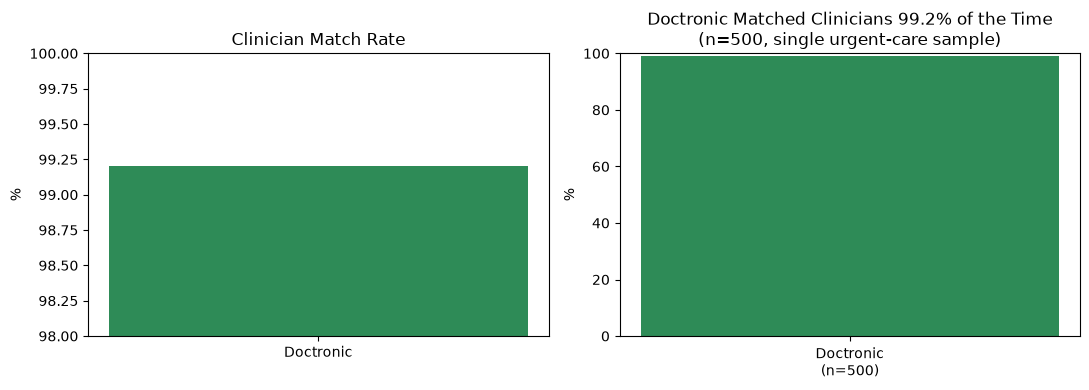

In [22]:
import matplotlib.pyplot as plt                       # brings in the tool used to draw charts

match_rate = 99.2                                     # the headline statistic being charted
n = 500                                               # how many cases that statistic is based on

fig, axes = plt.subplots(1, 2, figsize=(11, 4))       # sets up two charts side by side

# Version 1: the misleading version - truncated axis, no sample size, no comparison
axes[0].bar(["Doctronic"], [match_rate], color="seagreen")   # draws the bar for the misleading version
axes[0].set_ylim(98, 100)  # truncated axis exaggerates how close to perfect this looks
axes[0].set_title("Clinician Match Rate")  # states the topic, not the finding
axes[0].set_ylabel("%")                               # labels the vertical axis as a percentage

# Version 2: the honest version - full axis, sample size labeled, comparison shown
axes[1].bar(["Doctronic\n(n=500)"], [match_rate], color="seagreen")   # draws the bar for the honest version
axes[1].set_ylim(0, 100)  # full, honest scale
axes[1].set_title("Doctronic Matched Clinicians 99.2% of the Time\n(n=500, single urgent-care sample)")
axes[1].set_ylabel("%")                               # labels the vertical axis as a percentage

plt.tight_layout()                                    # neatens up the spacing between the two charts
plt.show()                                             # displays both charts on screen

**Misleading choices in Version 1:**
- Truncated y-axis (98-100) exaggerates how close to perfect the bar looks, when the true gap
  to 100% is 4x smaller-looking than it visually appears.
- No sample size shown, hiding that this is a single 500-case sample rather than a broad,
  statistically robust result.
- No baseline or comparison (e.g., clinician-to-clinician agreement rate) to tell the viewer
  whether 99.2% is actually exceptional or simply in line with normal human variation.

**Corrected title for Version 2:** "Doctronic Matched Clinicians 99.2% of the Time (n=500, single
urgent-care sample)"

**Corrected axis label(s):** y-axis labeled "%" on a full 0-100 scale; x-axis tick labeled
"Doctronic (n=500)" so the sample size travels with the number wherever the chart is shown.

---
##### Segment 10: Building Charts - Matplotlib, Seaborn, Plotly
**Core concept:** Chart Selection, Static vs. Interactive Visualization

**Background:** Turn your `audit.db` - the same database you built the audit trail into - into the
monthly report the state contract requires.

**Starter code:** pull data straight from the in-notebook audit DB (built in Segment 7) and build
three report-ready charts.

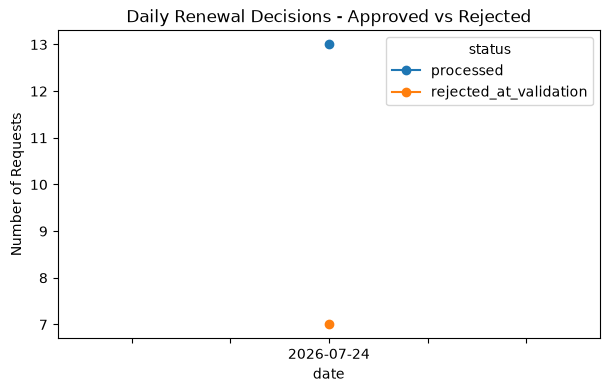

C:\Users\anjali.ancy\AppData\Local\Temp\ipykernel_29028\3137322633.py:18: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()                                     # neatens up the spacing


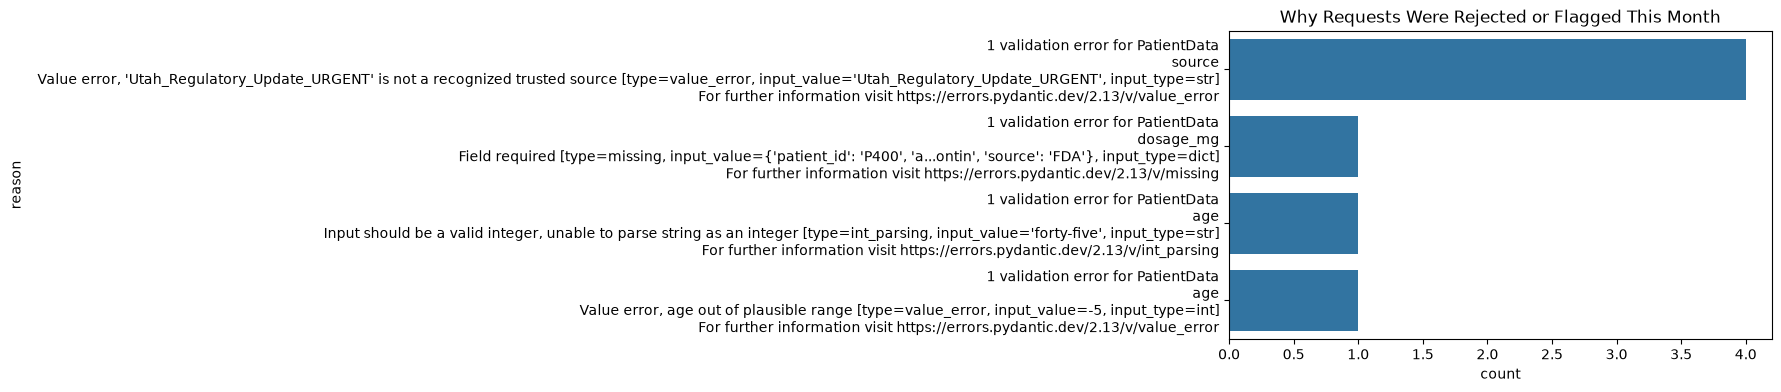

In [23]:
import seaborn as sns                                 # brings in a tool for nicer statistical charts
import plotly.express as px                            # brings in a tool for interactive, clickable charts

df = pd.read_sql_query("SELECT * FROM decisions", conn)   # pull every logged decision into a table
df["date"] = df["timestamp"].str[:10]                  # keep just the date part of each timestamp

# 1. Matplotlib - approvals vs rejections over time (trend -> line chart)
daily = df.groupby(["date", "status"]).size().unstack(fill_value=0)   # count outcomes per day
daily.plot(kind="line", marker="o", figsize=(7, 4))    # draw a line chart of outcomes over time
plt.title("Daily Renewal Decisions - Approved vs Rejected")
plt.ylabel("Number of Requests")
plt.show()                                             # display the line chart

# 2. Seaborn - distribution of rejection reasons (categorical comparison -> bar)
plt.figure(figsize=(7, 4))                             # start a new, blank chart
sns.countplot(data=df[df["status"] != "processed"], y="reason")   # count how often each rejection reason occurs
plt.title("Why Requests Were Rejected or Flagged This Month")
plt.tight_layout()                                     # neatens up the spacing
plt.show()                                             # display the bar chart

# 3. Plotly - interactive drill-down for the regulator to explore themselves
fig = px.histogram(df, x="date", color="status",       # build an interactive chart of volume by day and outcome
                    title="Renewal Volume by Outcome (interactive)")
fig.show()                                             # display the interactive chart

**Chart type justification:**

- Matplotlib (line): a regulator's first question is "is this trending better or worse over
  time," and a line chart is the form built specifically to show change across a continuous axis
  like dates.
- Seaborn (bar): rejection reasons are discrete categories, and a bar chart lets the regulator
  compare "which failure mode happens most often" at a glance, which a line or scatter would
  obscure.
- Plotly (interactive histogram): a static report goes stale the day after it's sent, so an
  interactive chart lets the regulator filter and drill into specific outcomes or date ranges on
  their own schedule instead of waiting for a new report.

---
##### Segment 11: Streamlit - The Living Dashboard
**Core concept:** Rapid App Building, Always-Current Reporting

**Background:** A monthly PDF report is already out of date the day after it's sent. The regulator
needs something they can check on their own schedule.

**Note:** Streamlit apps don't run inline in a notebook - they run as a standalone script via
`streamlit run app.py`. The cell below writes the completed app (with the student task's three
refinements applied) to a file so you can launch it from a terminal.

In [24]:
streamlit_app_code = '''
import streamlit as st                                 # brings in the tool for building the live dashboard page
import sqlite3                                          # brings in a tool for reading the stored records
import pandas as pd                                     # brings in a tool for working with tables of data

st.title("Prescription Renewal Oversight Dashboard")    # sets the page title a viewer sees

conn = sqlite3.connect("audit.db")                      # opens the saved record book from disk
df = pd.read_sql_query("SELECT * FROM decisions", conn) # pulls every logged decision into a table
df["timestamp"] = pd.to_datetime(df["timestamp"])       # converts the timestamp text into real dates

status_filter = st.multiselect("Filter by status", df["status"].unique(), default=df["status"].unique())   # lets the viewer pick which outcomes to see

# 1. Date-range filter so a regulator can inspect a specific week.
min_date, max_date = df["timestamp"].min().date(), df["timestamp"].max().date()   # find the earliest and latest dates logged
date_range = st.date_input("Date range", value=(min_date, max_date))   # lets the viewer pick a specific date range
if isinstance(date_range, tuple) and len(date_range) == 2:   # if the viewer picked a start and end date
    start_date, end_date = date_range
else:                                                    # otherwise, treat it as a single day
    start_date = end_date = date_range

filtered = df[                                           # narrow the table down to what the viewer asked for
    df["status"].isin(status_filter)
    & (df["timestamp"].dt.date >= start_date)
    & (df["timestamp"].dt.date <= end_date)
]

st.metric("Total requests logged", len(df))              # shows the all-time total request count
st.metric("Flagged for physician review", len(filtered[filtered["status"] != "processed"]))   # shows how many need human review

# 2. Visible callout when flagged requests exceed a threshold.
FLAG_THRESHOLD = 5                                       # how many flags are needed before we raise an alert
flagged_count = len(filtered[filtered["reason"].str.contains("controlled substance", na=False)])   # count controlled-substance flags
if flagged_count >= FLAG_THRESHOLD:                      # if we've crossed the alert threshold
    st.warning(f"{flagged_count} controlled-substance flags in this range - review recommended")   # show a warning banner

st.bar_chart(filtered["status"].value_counts())          # shows a simple bar chart of outcomes

# 3. Stretch goal: surface the reason text next to each flagged row.
st.subheader("Flagged requests")                         # a section heading for flagged requests
flagged_rows = filtered[filtered["status"] != "processed"][["patient_id", "status", "reason", "timestamp"]]   # pull just the flagged rows
st.dataframe(flagged_rows.sort_values("timestamp", ascending=False))   # display them, most recent first

st.subheader("All requests")                             # a section heading for every request
st.dataframe(filtered.sort_values("timestamp", ascending=False))   # display every request, most recent first
'''

with open("dashboard_app.py", "w") as f:                 # open a new file for writing
    f.write(streamlit_app_code)                          # save the dashboard code into that file

print("Wrote dashboard_app.py - run it with: streamlit run dashboard_app.py")   # confirm the file was saved
print("(Make sure audit.db exists on disk in the same folder - export your in-memory conn if needed.)")

Wrote dashboard_app.py - run it with: streamlit run dashboard_app.py
(Make sure audit.db exists on disk in the same folder - export your in-memory conn if needed.)


##### Steps to run the dashboard: 
1. Do Control + J (Windows)/Command + J (MAC) to open the terminal
2. Write in streamlit run dashboard_app.py and press enter
3. Use Control + C to terminate the process

**Student task recap - what was added to `dashboard_app.py`:**

1. A date-range filter (`st.date_input`) so a regulator can inspect a specific week.
2. A visible callout (`st.warning`) when controlled-substance flags in the selected range reach
   or exceed a threshold (5, in this solution).
3. **Stretch goal:** a dedicated "Flagged requests" table that surfaces the `reason` column next
   to each flagged row, so the regulator never has to ask why a request was routed for review.

Run on terminal (Three dots on the top left->Terminal: _streamlit run dashboard_app.py_

---
##### Closing: Ship It

By the end of this notebook, your system rejects malformed data at the door, refuses dangerous
decisions regardless of how convincing the source looks, logs every decision it makes, has been
tested against the exact attack that got the original pilot suspended, and reports its own
performance honestly.

Commit this notebook to your repo alongside your `dashboard_app.py` - this is part of your
portfolio-ready deliverable.